# 05 — 비용 시뮬레이션
예측값 기반 발주량을 결정하고, 재고 유지 비용(HoldingCost)과 품절 비용(StockoutCost)을 계산합니다.  
SMAPE가 낮은 모델이 실제 운영 비용도 낮은지를 검증합니다.

$$\text{TotalCost} = \text{HoldingCost} + \text{StockoutCost}$$

$$\text{HoldingCost}  = \max(\text{Order} - \text{Demand},\ 0) \times h$$

$$\text{StockoutCost} = \max(\text{Demand} - \text{Order},\ 0) \times s$$

---
| 셀 | 내용 |
|---|---|
| 3 | 비용 파라미터 설계 (카테고리별 h, s) |
| 4 | 발주 전략 정의 |
| 5 | 비용 시뮬레이션 실행 |
| 6 | 모델별 총비용 비교표 |
| 7 | SMAPE vs TotalCost 산점도 |
| 8 | 누적 비용 추이 시각화 |
| 9 | h·s 민감도 분석 |
| 10 | 종합 결론 |

## 1. 라이브러리

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi'       : 120,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.alpha'       : 0.3,
    'font.size'        : 9,
})

MODEL_COLORS = {
    'ARIMA'   : '#378ADD',
    'XGBoost' : '#1D9E75',
    'LSTM'    : '#D85A30',
    'Perfect' : '#7F77DD',   # 완벽한 예측 (이론적 하한)
    'Naive'   : '#999999',   # 전일값 그대로 발주 (baseline)
}
MODEL_KEYS = ['ARIMA', 'XGBoost', 'LSTM', 'Perfect', 'Naive']

print("라이브러리 로드 완료")

라이브러리 로드 완료


## 2. 데이터 로드

In [14]:
pred_df   = pd.read_csv('../data/predictions.csv',  parse_dates=['date'])
smape_df  = pd.read_csv('../data/smape_summary.csv')

# 배송비 평균 (카테고리별 h 설정용) ─ 원본 데이터에서 계산
path        = '../data/'
orders      = pd.read_csv(path + 'olist_orders_dataset.csv')
order_items = pd.read_csv(path + 'olist_order_items_dataset.csv')
products    = pd.read_csv(path + 'olist_products_dataset.csv')

orders['order_date'] = pd.to_datetime(orders['order_purchase_timestamp']).dt.normalize()
merged_cost = (
    pd.merge(orders[['order_id']], order_items[['order_id','product_id','freight_value']], on='order_id')
    .merge(products[['product_id','product_category_name']], on='product_id')
    .dropna(subset=['product_category_name'])
)
freight_by_cat = (
    merged_cost
    .groupby('product_category_name')['freight_value']
    .mean()
    .rename('avg_freight')
)

CATEGORIES = pred_df['category'].unique().tolist()

print("데이터 로드 완료")
print("카테고리 수:", len(CATEGORIES))
pred_df.head(3)

데이터 로드 완료
카테고리 수: 10


,date,category,actual,pred_arima,pred_xgb,pred_lstm
0,2018-07-01,cama_mesa_banho,19.0,18.041348,19.670480,22.899727
1,2018-07-02,cama_mesa_banho,19.0,18.401553,26.488190,22.675919
2,2018-07-03,cama_mesa_banho,25.0,18.567984,24.896883,22.104588


## 3. 비용 파라미터 설계

### h (재고 유지 비용 per unit·day)
- 카테고리별 **평균 배송비**를 h의 기준으로 사용합니다
- 배송비가 높은 카테고리 = 부피·무게가 크다 = 보관 비용도 높다는 가정
- `h = avg_freight × h_scale` 로 정규화합니다

### s (품절 비용 per unit·day)
- 일반적으로 s > h (기회비용 + 고객 이탈)
- `s = h × s_ratio` 로 설정합니다 (기본값 s_ratio = 3)

> **민감도 분석(셀 9)** 에서 h_scale과 s_ratio를 변경하며 결론이 바뀌는지 검증합니다.

In [15]:
H_SCALE = 0.1    # avg_freight × H_SCALE = h
S_RATIO = 3.0    # s = h × S_RATIO

cost_params = {}

for cat in CATEGORIES:
    avg_f = freight_by_cat.get(cat, freight_by_cat.mean())
    h     = round(avg_f * H_SCALE, 4)
    s     = round(h * S_RATIO, 4)
    cost_params[cat] = {'h': h, 's': s, 'avg_freight': round(avg_f, 2)}

params_df = pd.DataFrame(cost_params).T.reset_index()
params_df.columns = ['category', 'h', 's', 'avg_freight']

print(f"비용 파라미터 (H_SCALE={H_SCALE}, S_RATIO={S_RATIO})")
print(params_df.sort_values('h', ascending=False).to_string(index=False))

비용 파라미터 (H_SCALE=0.1, S_RATIO=3.0)
              category      h      s  avg_freight
    ferramentas_jardim 2.2766 6.8298        22.77
            automotivo 2.1881 6.5643        21.88
 utilidades_domesticas 2.0986 6.2958        20.99
      moveis_decoracao 2.0728 6.2184        20.73
         esporte_lazer 1.9512 5.8536        19.51
          beleza_saude 1.8880 5.6640        18.88
informatica_acessorios 1.8822 5.6466        18.82
       cama_mesa_banho 1.8416 5.5248        18.42
    relogios_presentes 1.6781 5.0343        16.78
             telefonia 1.5669 4.7007        15.67


## 4. 발주 전략 정의

예측값을 그대로 발주량으로 쓰는 것이 항상 최적은 아닙니다.  
s > h 구조에서는 품절이 더 비싸므로 **예측값보다 약간 더 발주**하는 것이 유리할 수 있습니다.

| 전략 | 설명 |
|---|---|
| `exact` | 예측값 그대로 발주 |
| `safety` | 예측값 + 안전재고 (rolling_std 기반) |
| `newsvendor` | 뉴스벤더 최적 분위수 기반 발주 |

In [16]:
from scipy.stats import norm


def order_quantity(pred: np.ndarray, strategy: str,
                   h: float, s: float,
                   rolling_std: np.ndarray = None) -> np.ndarray:
    """
    발주량 결정 전략.

    Args:
        pred        : 예측 수요 (1D array)
        strategy    : 'exact' | 'safety' | 'newsvendor'
        h           : 재고 유지 비용
        s           : 품절 비용
        rolling_std : 수요 표준편차 (safety / newsvendor 전략에 필요)

    Returns:
        order : 발주량 (1D array, 음수 없음)
    """
    pred = np.maximum(0, np.array(pred, dtype=float))

    if strategy == 'exact':
        order = pred

    elif strategy == 'safety':
        # 안전재고 = z × σ  (z=1.0, 서비스 수준 84%)
        z   = norm.ppf(s / (s + h))   # 뉴스벤더 최적 z
        std = rolling_std if rolling_std is not None else np.ones_like(pred)
        order = pred + z * std

    elif strategy == 'newsvendor':
        # 뉴스벤더 최적 발주 분위수 q* = s / (s + h)
        # 수요가 정규분포라 가정: Order = μ + z*σ
        q   = s / (s + h)
        z   = norm.ppf(q)
        std = rolling_std if rolling_std is not None else np.ones_like(pred)
        order = pred + z * std

    else:
        raise ValueError(f"알 수 없는 전략: {strategy}")

    return np.maximum(0, order)


print("발주 전략 함수 정의 완료")

# 뉴스벤더 최적 분위수 미리 확인
print("\n카테고리별 뉴스벤더 최적 발주 분위수 q* = s/(s+h)")
for cat in CATEGORIES[:5]:
    h = cost_params[cat]['h']
    s = cost_params[cat]['s']
    q = s / (s + h)
    print(f"  {cat[:30]:<30}  h={h:.4f}  s={s:.4f}  q*={q:.3f}")

발주 전략 함수 정의 완료

카테고리별 뉴스벤더 최적 발주 분위수 q* = s/(s+h)
  cama_mesa_banho                 h=1.8416  s=5.5248  q*=0.750
  beleza_saude                    h=1.8880  s=5.6640  q*=0.750
  esporte_lazer                   h=1.9512  s=5.8536  q*=0.750
  moveis_decoracao                h=2.0728  s=6.2184  q*=0.750
  informatica_acessorios          h=1.8822  s=5.6466  q*=0.750


## 5. 비용 시뮬레이션 실행

In [17]:
def simulate_cost(actual: np.ndarray, order: np.ndarray,
                  h: float, s: float) -> dict:
    """
    일별 비용을 계산합니다.

    Returns:
        dict: holding, stockout, total (각각 1D array + 합계)
    """
    actual  = np.array(actual, dtype=float)
    order   = np.array(order,  dtype=float)

    holding  = np.maximum(order - actual, 0) * h
    stockout = np.maximum(actual - order, 0) * s
    total    = holding + stockout

    return {
        'holding_daily' : holding,
        'stockout_daily': stockout,
        'total_daily'   : total,
        'holding_sum'   : holding.sum(),
        'stockout_sum'  : stockout.sum(),
        'total_sum'     : total.sum(),
    }


STRATEGY = 'newsvendor'  # 'exact' | 'safety' | 'newsvendor'

# 결과 저장
cost_results = {}   # {category: {model: {holding, stockout, total, ...}}}
cost_daily_rows = [] # 날짜별 비용 저장 (시각화용)

pred_cols = {
    'ARIMA'  : 'pred_arima',
    'XGBoost': 'pred_xgb',
    'LSTM'   : 'pred_lstm',
}

for cat in CATEGORIES:
    sub = pred_df[pred_df['category'] == cat].sort_values('date')
    sub = sub.dropna(subset=list(pred_cols.values()))   # 공통 NaN 제거

    actual = sub['actual'].values
    dates  = sub['date'].values
    h      = cost_params[cat]['h']
    s      = cost_params[cat]['s']

    # rolling_std: feature engineering 결과 없으면 실제 rolling std 사용
    rolling_std = pd.Series(actual).shift(1).rolling(7, min_periods=2).std().fillna(1).values

    cost_results[cat] = {}

    # ── 세 예측 모델 ──────────────────────────────────
    for model, col in pred_cols.items():
        pred   = sub[col].values
        order  = order_quantity(pred, STRATEGY, h, s, rolling_std)
        result = simulate_cost(actual, order, h, s)
        cost_results[cat][model] = result

        for t, dt in enumerate(dates):
            cost_daily_rows.append({
                'date'    : dt,
                'category': cat,
                'model'   : model,
                'actual'  : actual[t],
                'order'   : order[t],
                'holding' : result['holding_daily'][t],
                'stockout': result['stockout_daily'][t],
                'total'   : result['total_daily'][t],
            })

    # ── Perfect 예측 (이론적 비용 하한) ──────────────
    order_perfect = order_quantity(actual, STRATEGY, h, s, rolling_std)
    result_perfect = simulate_cost(actual, order_perfect, h, s)
    cost_results[cat]['Perfect'] = result_perfect

    # ── Naive (전일 수요를 발주량으로 사용) ───────────
    naive_pred  = np.concatenate([[actual[0]], actual[:-1]])
    order_naive = order_quantity(naive_pred, STRATEGY, h, s, rolling_std)
    result_naive = simulate_cost(actual, order_naive, h, s)
    cost_results[cat]['Naive'] = result_naive


cost_daily_df = pd.DataFrame(cost_daily_rows)
print(f"비용 시뮬레이션 완료 (전략: {STRATEGY})")
print(f"일별 비용 데이터: {cost_daily_df.shape}")

비용 시뮬레이션 완료 (전략: newsvendor)
일별 비용 데이터: (1860, 8)


## 6. 모델별 총비용 비교표

In [18]:
# ── 비용 비교 테이블 생성 ─────────────────────────────
cost_rows = []
for cat in CATEGORIES:
    row = {'category': cat}
    for model in MODEL_KEYS:
        r = cost_results[cat][model]
        row[f'holding_{model}']  = r['holding_sum']
        row[f'stockout_{model}'] = r['stockout_sum']
        row[f'total_{model}']    = r['total_sum']
    # 세 예측 모델 중 총비용 최소 모델
    row['best_cost_model'] = min(
        ['ARIMA', 'XGBoost', 'LSTM'],
        key=lambda m: row[f'total_{m}']
    )
    cost_rows.append(row)

cost_df = pd.DataFrame(cost_rows)

# ── 출력: 총비용 비교 ────────────────────────────────
disp_cols = ['category'] + [f'total_{m}' for m in MODEL_KEYS] + ['best_cost_model']
print("총비용 비교표 (단위: BRL, 낮을수록 좋음)")
print("=" * 80)
print(cost_df[disp_cols].to_string(index=False, float_format=lambda x: f'{x:,.1f}'))

print("\n── 전체 합산 총비용 ──")
for m in MODEL_KEYS:
    total = cost_df[f'total_{m}'].sum()
    hold  = cost_df[f'holding_{m}'].sum()
    stock = cost_df[f'stockout_{m}'].sum()
    print(f"  {m:<10}: {total:>12,.1f}  (보관={hold:,.1f} / 품절={stock:,.1f})")

print("\n── 비용 기준 1위 카테고리 수 ──")
print(cost_df['best_cost_model'].value_counts().to_string())

총비용 비교표 (단위: BRL, 낮을수록 좋음)
              category  total_ARIMA  total_XGBoost  total_LSTM  total_Perfect  total_Naive best_cost_model
       cama_mesa_banho      1,324.0        1,363.7     1,577.2          517.4      1,267.7           ARIMA
          beleza_saude      1,577.9        1,579.1     1,808.1          695.9      1,644.2           ARIMA
         esporte_lazer      1,036.8          980.4     1,099.5          420.9      1,068.3         XGBoost
      moveis_decoracao      1,301.5        1,341.2     1,437.6          504.7      1,304.8           ARIMA
informatica_acessorios      1,091.8          984.5     1,143.9          418.5      1,183.3         XGBoost
 utilidades_domesticas      1,619.4        1,587.4     1,859.3          642.5      1,574.7         XGBoost
    relogios_presentes        761.0          893.7       980.3          331.4        795.9           ARIMA
             telefonia        561.7          555.2       591.6          215.2        560.5         XGBoost
    ferram

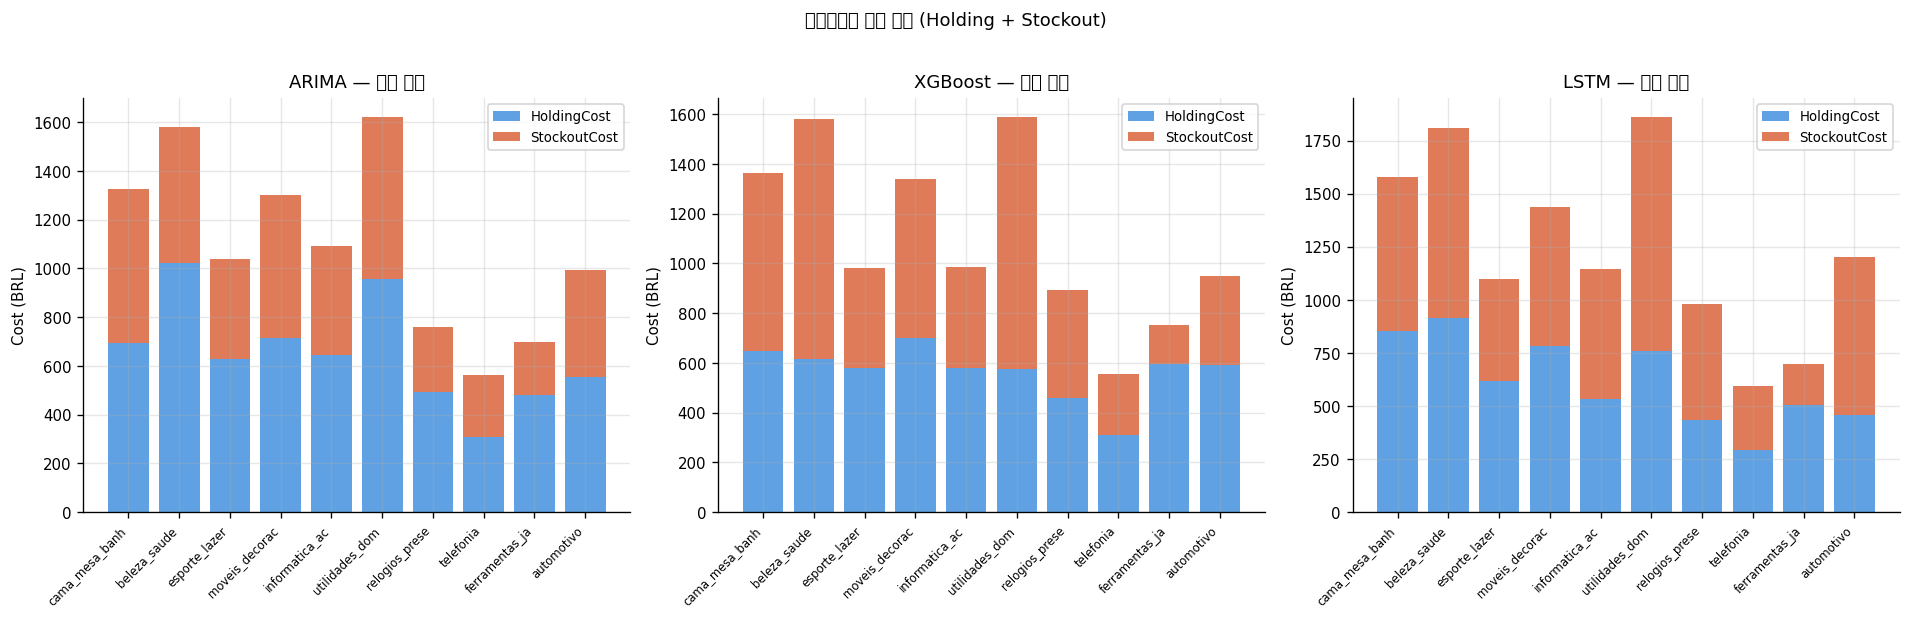

In [19]:
# ── 비용 구성 스택바 (카테고리별) ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, model in zip(axes, ['ARIMA', 'XGBoost', 'LSTM']):
    h_vals = cost_df[f'holding_{model}'].values
    s_vals = cost_df[f'stockout_{model}'].values
    x      = np.arange(len(CATEGORIES))

    ax.bar(x, h_vals, label='HoldingCost',  color='#378ADD', alpha=0.8)
    ax.bar(x, s_vals, label='StockoutCost', color='#D85A30', alpha=0.8, bottom=h_vals)

    ax.set_title(f'{model} — 비용 구성')
    ax.set_xticks(x)
    ax.set_xticklabels([c[:14] for c in CATEGORIES], rotation=45, ha='right', fontsize=7)
    ax.set_ylabel('Cost (BRL)')
    ax.legend(fontsize=8)

plt.suptitle('카테고리별 비용 구성 (Holding + Stockout)', y=1.02)
plt.tight_layout()
plt.show()

## 7. 핵심 질문 — SMAPE vs TotalCost

**"예측 정확도가 높을수록 운영 비용도 반드시 낮은가?"**  
카테고리 × 모델을 점으로 찍어서 SMAPE와 TotalCost의 관계를 확인합니다.

SMAPE ↔ TotalCost 상관관계
  Pearson  r = -0.453  (p=0.012)
  Spearman r = -0.391  (p=0.033)
  → 중간 상관관계: 대체로 관련 있으나 예외 카테고리 존재


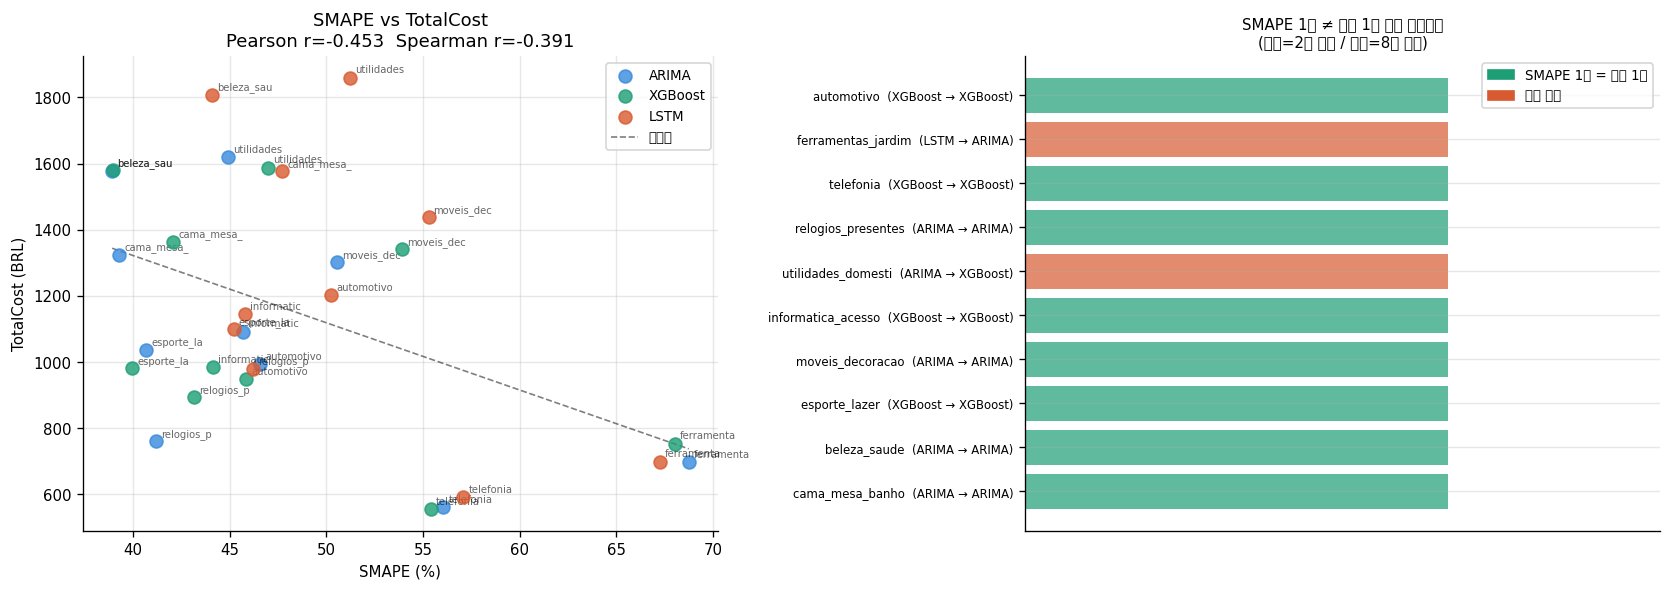


역전 발생: 2/10개 카테고리
             category best_smape best_cost  reversed
utilidades_domesticas      ARIMA   XGBoost      True
   ferramentas_jardim       LSTM     ARIMA      True


In [20]:
from scipy.stats import pearsonr, spearmanr

scatter_rows = []
for cat in CATEGORIES:
    for model in ['ARIMA', 'XGBoost', 'LSTM']:
        smape_val = smape_df.loc[
            smape_df['category'] == cat, model_col_map[model]
            ].values
        if len(smape_val) == 0:
            continue
        scatter_rows.append({
            'category'  : cat,
            'model'     : model,
            'smape'     : smape_val[0],
            'total_cost': cost_results[cat][model]['total_sum'],
        })

scatter_df = pd.DataFrame(scatter_rows)

# ── 상관관계 ──────────────────────────────────────────
pearson_r,  p_pearson  = pearsonr(scatter_df['smape'], scatter_df['total_cost'])
spearman_r, p_spearman = spearmanr(scatter_df['smape'], scatter_df['total_cost'])

print("SMAPE ↔ TotalCost 상관관계")
print(f"  Pearson  r = {pearson_r:.3f}  (p={p_pearson:.3f})")
print(f"  Spearman r = {spearman_r:.3f}  (p={p_spearman:.3f})")
if abs(pearson_r) < 0.3:
    print("  → 상관관계 약함: SMAPE가 낮아도 비용이 낮지 않을 수 있음")
elif abs(pearson_r) < 0.6:
    print("  → 중간 상관관계: 대체로 관련 있으나 예외 카테고리 존재")
else:
    print("  → 강한 상관관계: SMAPE와 비용이 함께 움직임")

# ── 산점도 ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 좌: 전체 산점도 (모델별 색)
ax = axes[0]
for model in ['ARIMA', 'XGBoost', 'LSTM']:
    sub = scatter_df[scatter_df['model'] == model]
    ax.scatter(sub['smape'], sub['total_cost'],
               color=MODEL_COLORS[model], label=model,
               s=60, alpha=0.8, zorder=3)
    # 카테고리명 라벨
    for _, row in sub.iterrows():
        ax.annotate(row['category'][:10],
                    (row['smape'], row['total_cost']),
                    fontsize=6, alpha=0.6,
                    xytext=(3, 3), textcoords='offset points')

# 추세선
z = np.polyfit(scatter_df['smape'], scatter_df['total_cost'], 1)
p = np.poly1d(z)
xline = np.linspace(scatter_df['smape'].min(), scatter_df['smape'].max(), 100)
ax.plot(xline, p(xline), 'k--', linewidth=1, alpha=0.5, label='추세선')

ax.set_xlabel('SMAPE (%)')
ax.set_ylabel('TotalCost (BRL)')
ax.set_title(f'SMAPE vs TotalCost\nPearson r={pearson_r:.3f}  Spearman r={spearman_r:.3f}')
ax.legend(fontsize=8)

# 우: SMAPE 순위 vs 비용 순위 (카테고리별 역전 여부)
ax = axes[1]
rank_rows = []
for cat in CATEGORIES:
    smape_rank = {
        m: smape_df.loc[
            smape_df['category'] == cat, 
            model_col_map[m]].values[0] 
            for m in ['ARIMA', 'XGBoost', 'LSTM']}
    cost_rank = {
        m: cost_results[cat][m]['total_sum']
        for m in ['ARIMA','XGBoost','LSTM']
    }
    best_smape = min(smape_rank, key=smape_rank.get)
    best_cost  = min(cost_rank,  key=cost_rank.get)
    rank_rows.append({
        'category'  : cat,
        'best_smape': best_smape,
        'best_cost' : best_cost,
        'reversed'  : best_smape != best_cost,
    })

rank_comp = pd.DataFrame(rank_rows)
reversed_count = rank_comp['reversed'].sum()
total_count    = len(rank_comp)

colors = ['#D85A30' if r else '#1D9E75' for r in rank_comp['reversed']]
ax.barh(range(total_count), [1]*total_count, color=colors, alpha=0.7)
ax.set_yticks(range(total_count))
ax.set_yticklabels(
    [f"{r['category'][:18]}  ({r['best_smape']} → {r['best_cost']})"
     for _, r in rank_comp.iterrows()],
    fontsize=7
)
ax.set_xlim(0, 1.5)
ax.set_xticks([])
ax.set_title(
    f'SMAPE 1위 ≠ 비용 1위 역전 카테고리\n'
    f'(빨강={reversed_count}개 역전 / 초록={total_count-reversed_count}개 일치)',
    fontsize=9
)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#1D9E75', label='SMAPE 1위 = 비용 1위'),
    Patch(color='#D85A30', label='역전 발생'),
], fontsize=8)

plt.tight_layout()
plt.show()

print(f"\n역전 발생: {reversed_count}/{total_count}개 카테고리")
print(rank_comp[rank_comp['reversed']].to_string(index=False))

## 8. 누적 비용 추이 시각화

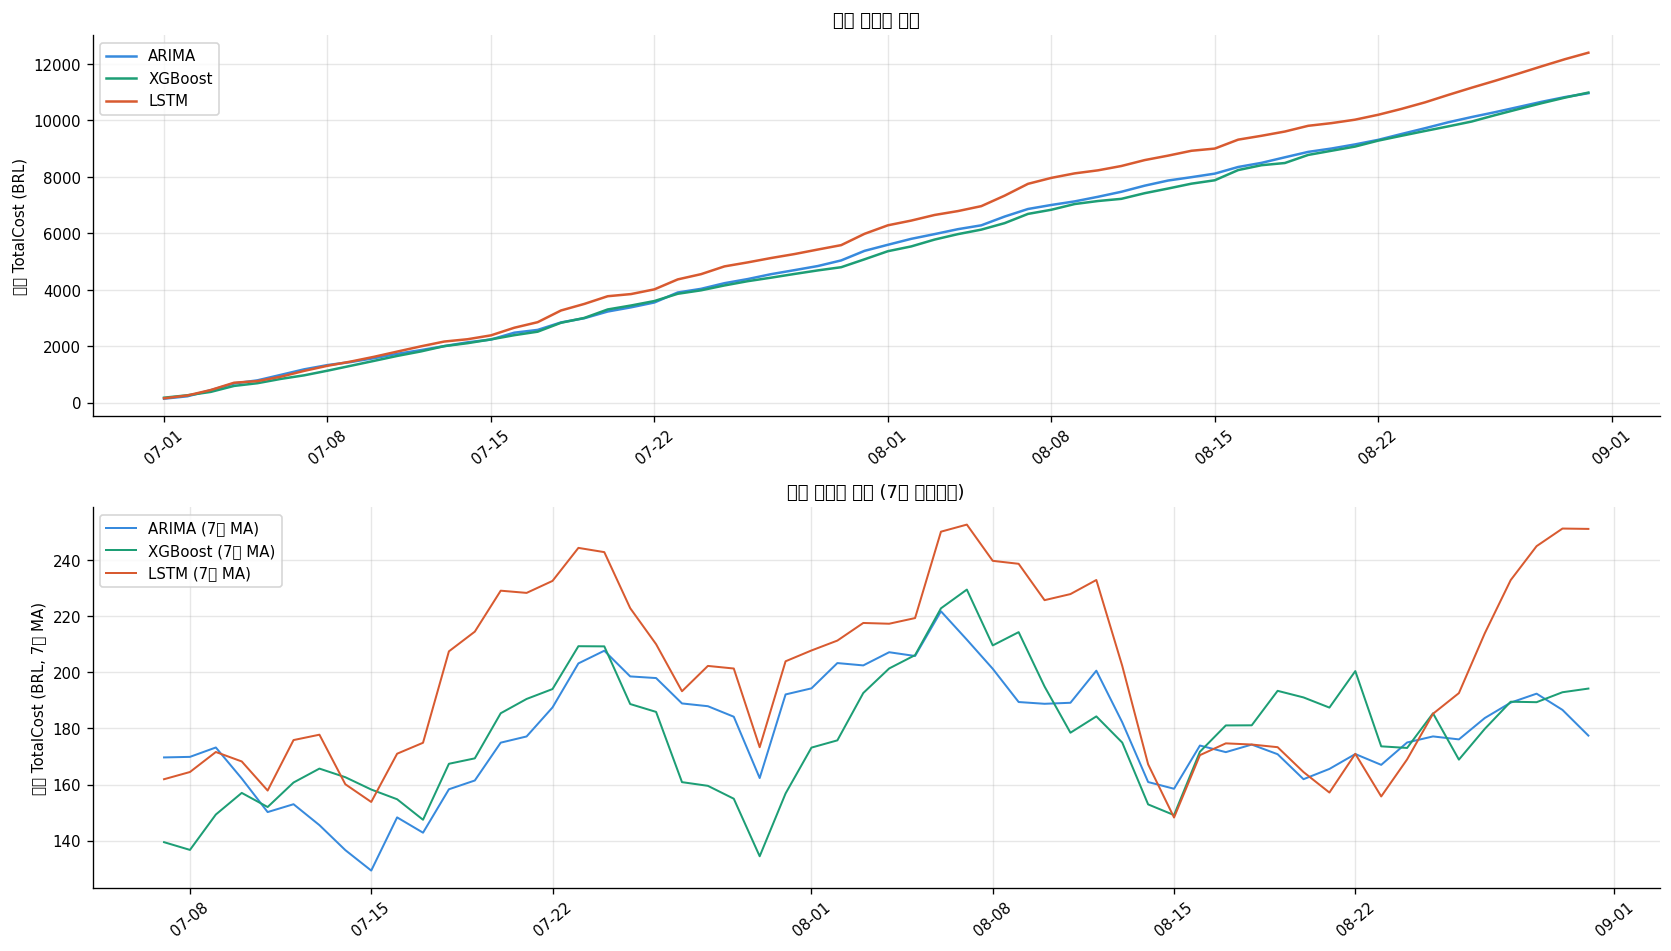

In [21]:
# 전체 카테고리 합산 — 날짜별 누적 비용
daily_total = (
    cost_daily_df
    .groupby(['date','model'])[['holding','stockout','total']]
    .sum()
    .reset_index()
)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# 상단: 누적 총비용
ax = axes[0]
for model in ['ARIMA','XGBoost','LSTM','Perfect','Naive']:
    sub = daily_total[daily_total['model'] == model].sort_values('date')
    if sub.empty:
        continue
    ax.plot(sub['date'], sub['total'].cumsum(),
            color=MODEL_COLORS[model], linewidth=1.5 if model not in ['Perfect','Naive'] else 1,
            linestyle='-' if model not in ['Perfect','Naive'] else ':',
            label=model)

ax.set_ylabel('누적 TotalCost (BRL)')
ax.set_title('누적 총비용 추이')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
ax.tick_params(axis='x', rotation=40)
ax.legend(fontsize=9)

# 하단: 일별 비용 (holding / stockout 분리)
ax = axes[1]
for model in ['ARIMA','XGBoost','LSTM']:
    sub = daily_total[daily_total['model'] == model].sort_values('date')
    ax.plot(sub['date'], sub['total'].rolling(7).mean(),
            color=MODEL_COLORS[model], linewidth=1.2, label=f'{model} (7일 MA)')

ax.set_ylabel('일별 TotalCost (BRL, 7일 MA)')
ax.set_title('일별 총비용 추이 (7일 이동평균)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
ax.tick_params(axis='x', rotation=40)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

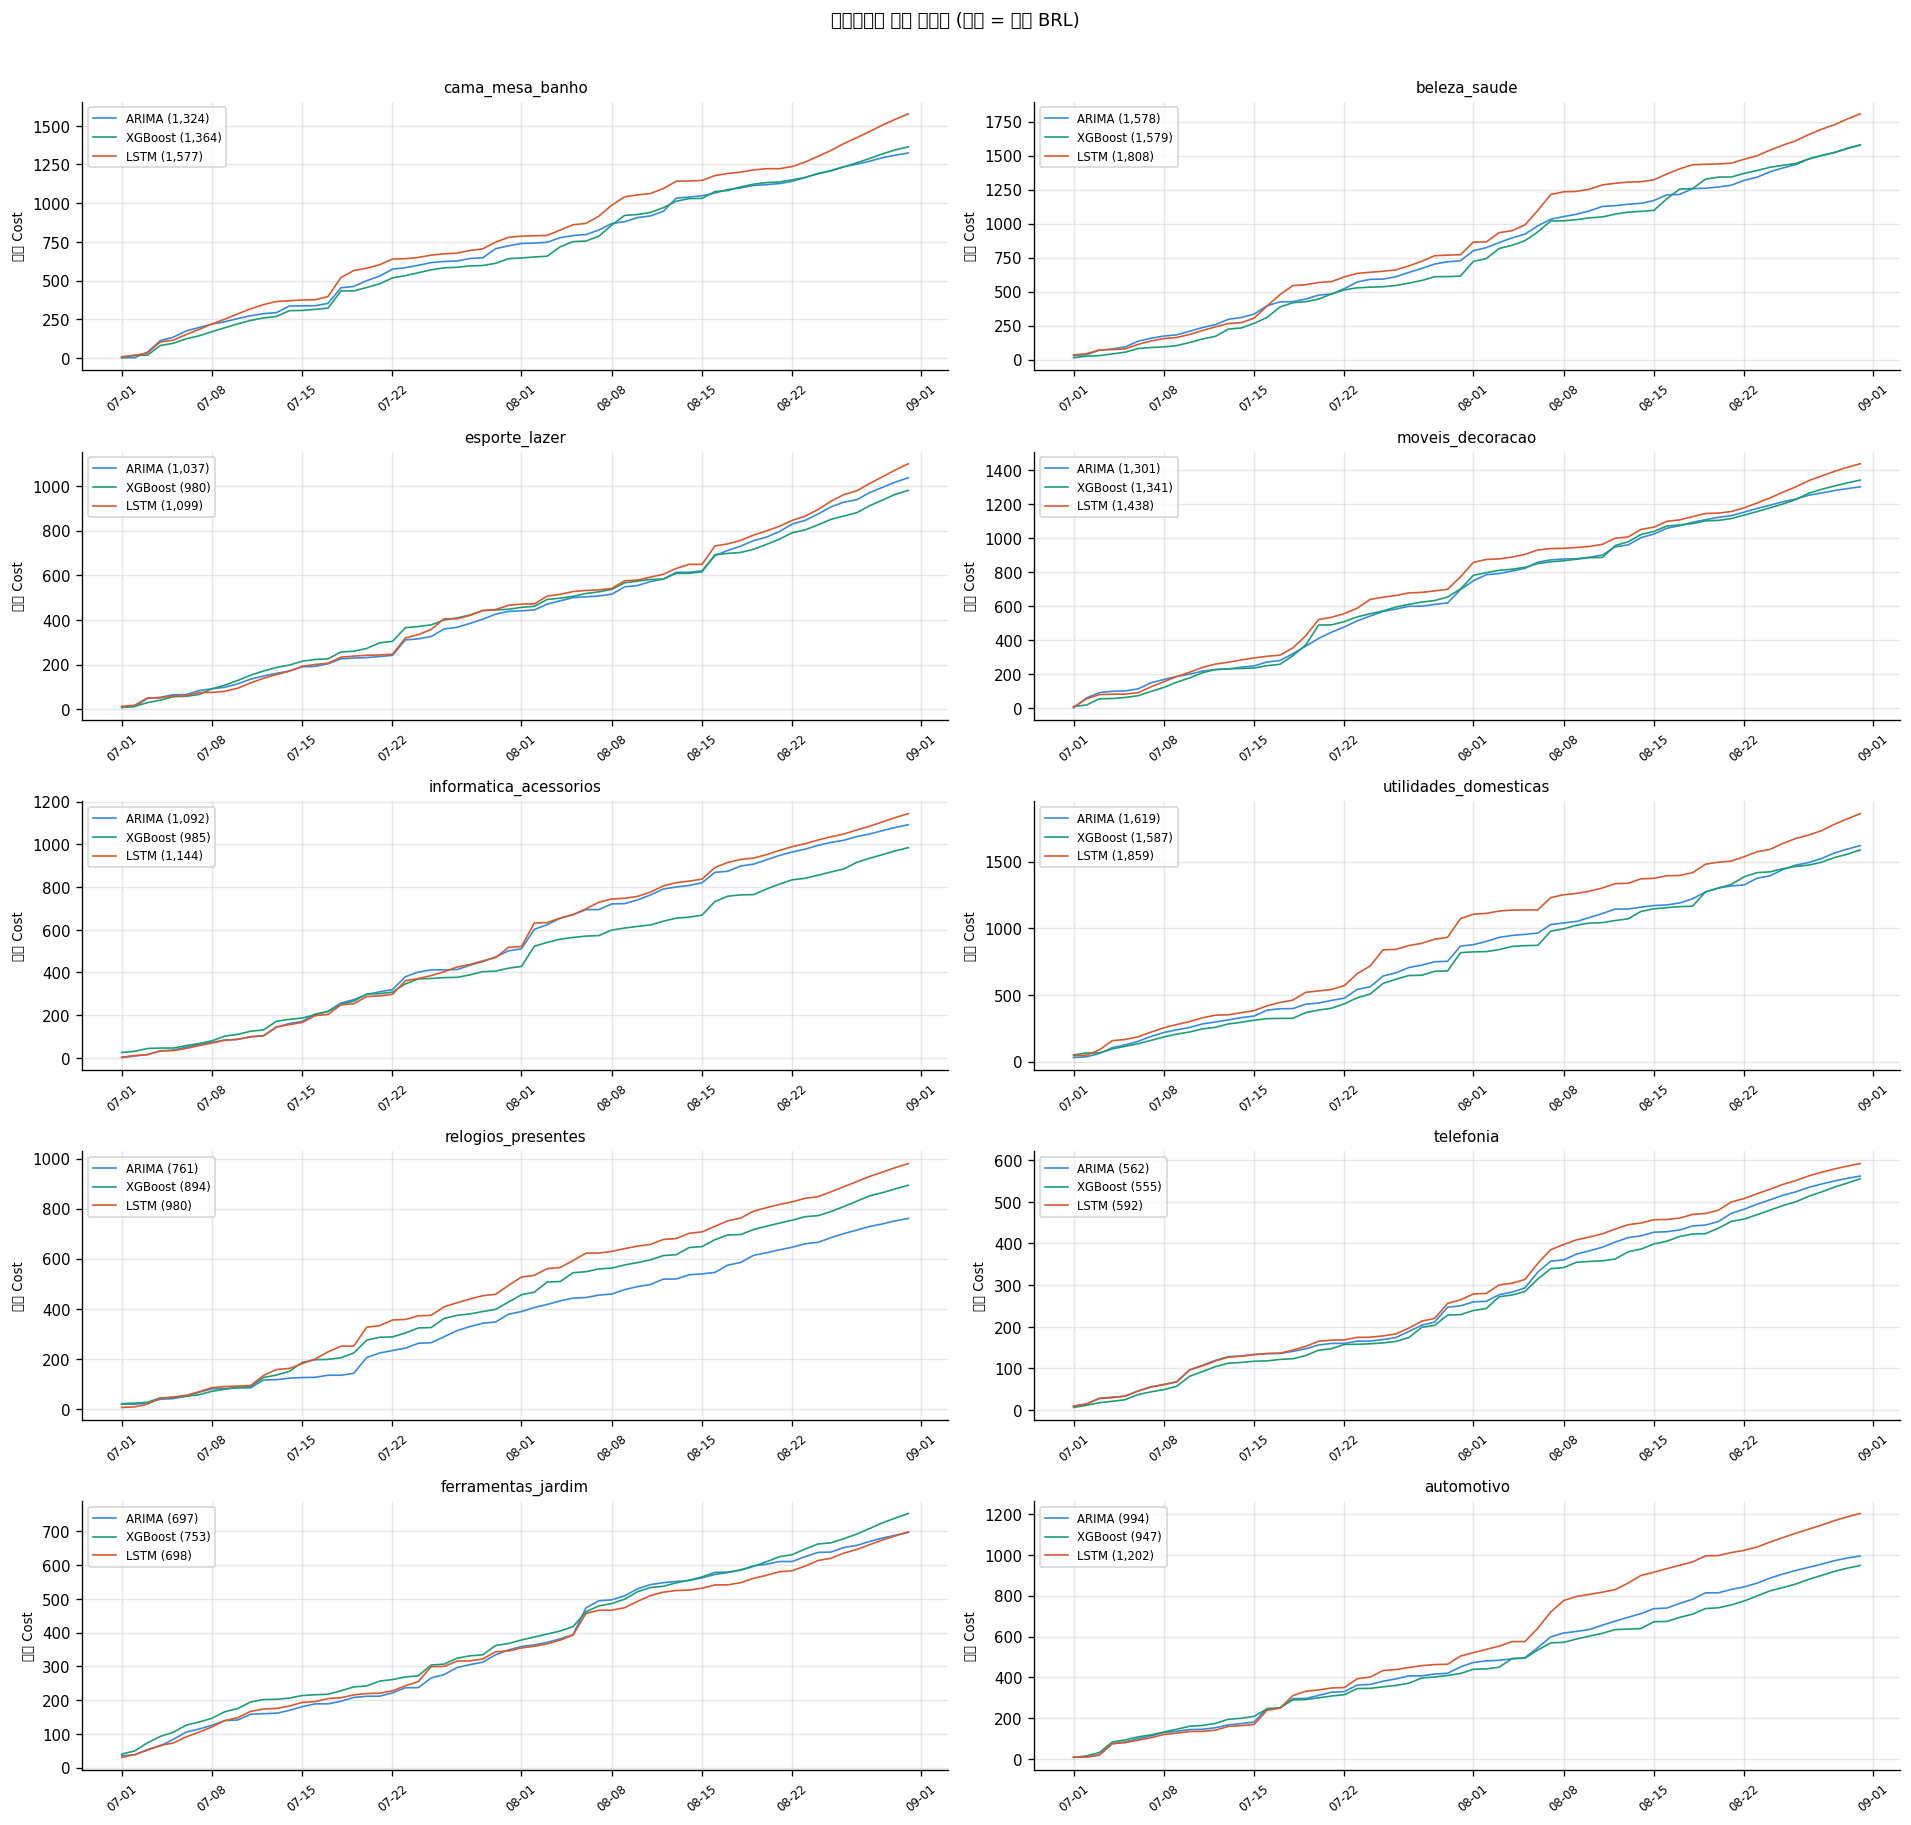

In [22]:
# 카테고리별 누적 비용 subplot
n_cols = 2
n_rows = (len(CATEGORIES) + 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, cat in enumerate(CATEGORIES):
    ax = axes[i]
    for model in ['ARIMA','XGBoost','LSTM']:
        r     = cost_results[cat][model]
        cumul = np.cumsum(r['total_daily'])
        dates = cost_daily_df[
            (cost_daily_df['category'] == cat) &
            (cost_daily_df['model'] == model)
        ]['date'].values
        ax.plot(dates, cumul,
                color=MODEL_COLORS[model], linewidth=1,
                label=f"{model} ({r['total_sum']:,.0f})")

    ax.set_title(cat, fontsize=9)
    ax.set_ylabel('누적 Cost', fontsize=8)
    ax.tick_params(axis='x', rotation=40, labelsize=7)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    ax.legend(fontsize=7)

for j in range(len(CATEGORIES), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('카테고리별 누적 총비용 (괄호 = 총합 BRL)', y=1.01)
plt.tight_layout()
plt.show()

## 9. h·s 민감도 분석

비용 파라미터(h_scale, s_ratio)가 달라졌을 때 모델 순위가 바뀌는지 확인합니다.  
순위가 바뀐다면 결론이 파라미터에 민감하다는 의미입니다.

h·s 민감도 분석 결과 (전체 카테고리 합산 총비용)
 h_scale  s_ratio best_model  total_ARIMA  total_XGBoost  total_LSTM
    0.05      2.0      ARIMA      4,455.2        4,520.8     5,096.3
    0.05      3.0      ARIMA      5,218.5        5,309.1     5,980.6
    0.05      5.0      ARIMA      6,123.1        6,328.7     7,131.8
    0.10      2.0      ARIMA      8,910.4        9,041.6    10,192.7
    0.10      3.0      ARIMA     10,437.0       10,618.3    11,961.2
    0.10      5.0      ARIMA     12,246.1       12,657.3    14,263.6
    0.20      2.0      ARIMA     17,820.8       18,083.2    20,385.4
    0.20      3.0      ARIMA     20,874.0       21,236.5    23,922.5
    0.20      5.0      ARIMA     24,492.2       25,314.7    28,527.2


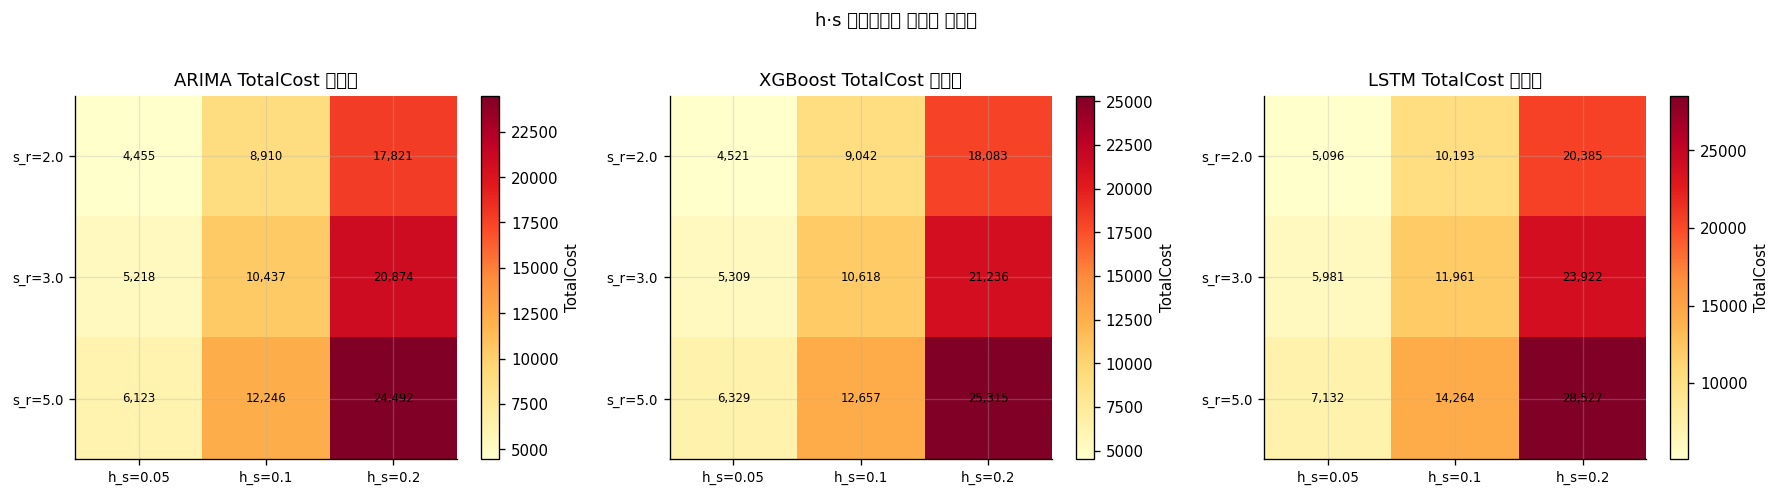

In [23]:
H_SCALE_LIST = [0.05, 0.10, 0.20]
S_RATIO_LIST = [2.0,  3.0,  5.0]

sensitivity_rows = []

for h_scale in H_SCALE_LIST:
    for s_ratio in S_RATIO_LIST:

        total_by_model = {m: 0 for m in ['ARIMA','XGBoost','LSTM']}

        for cat in CATEGORIES:
            sub = pred_df[pred_df['category'] == cat].sort_values('date')
            sub = sub.dropna(subset=['pred_arima','pred_xgb','pred_lstm'])
            actual = sub['actual'].values

            avg_f = freight_by_cat.get(cat, freight_by_cat.mean())
            h     = avg_f * h_scale
            s     = h * s_ratio
            rolling_std = pd.Series(actual).rolling(7, min_periods=2).std().fillna(1).values

            for model, col in pred_cols.items():
                pred  = sub[col].values
                order = order_quantity(pred, STRATEGY, h, s, rolling_std)
                cost  = simulate_cost(actual, order, h, s)
                total_by_model[model] += cost['total_sum']

        best = min(total_by_model, key=total_by_model.get)
        row  = {'h_scale': h_scale, 's_ratio': s_ratio, 'best_model': best}
        row.update({f'total_{m}': round(total_by_model[m], 1) for m in total_by_model})
        sensitivity_rows.append(row)

sens_df = pd.DataFrame(sensitivity_rows)

print("h·s 민감도 분석 결과 (전체 카테고리 합산 총비용)")
print("=" * 70)
print(sens_df.to_string(index=False, float_format=lambda x: f'{x:,.1f}' if x > 1 else f'{x:.2f}'))

# 히트맵
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, model in zip(axes, ['ARIMA','XGBoost','LSTM']):
    pivot = sens_df.pivot(index='s_ratio', columns='h_scale', values=f'total_{model}')
    im = ax.imshow(pivot.values, cmap='YlOrRd', aspect='auto')
    plt.colorbar(im, ax=ax, label='TotalCost')
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([f'h_s={v}' for v in pivot.columns], fontsize=8)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([f's_r={v}' for v in pivot.index], fontsize=8)
    ax.set_title(f'{model} TotalCost 민감도')
    for r in range(len(pivot.index)):
        for c in range(len(pivot.columns)):
            ax.text(c, r, f'{pivot.values[r,c]:,.0f}',
                    ha='center', va='center', fontsize=7)

plt.suptitle('h·s 파라미터별 총비용 민감도', y=1.02)
plt.tight_layout()
plt.show()

## 10. 종합 결론

In [24]:
print("=" * 65)
print("비용 시뮬레이션 종합 결론")
print("=" * 65)

# 1. 전체 총비용
print("\n[ 1. 전체 합산 총비용 ]")
for m in ['ARIMA','XGBoost','LSTM','Perfect','Naive']:
    total = sum(cost_results[cat][m]['total_sum'] for cat in CATEGORIES)
    hold  = sum(cost_results[cat][m]['holding_sum']  for cat in CATEGORIES)
    stock = sum(cost_results[cat][m]['stockout_sum'] for cat in CATEGORIES)
    print(f"  {m:<10}: {total:>12,.1f} BRL  (보관={hold:,.1f} / 품절={stock:,.1f})")

# 2. SMAPE vs 비용 역전 요약
print(f"\n[ 2. SMAPE 1위 ≠ 비용 1위 역전 ]")
print(f"  역전 발생: {reversed_count}/{total_count}개 카테고리")
if reversed_count > total_count // 2:
    print("  → 결론: SMAPE가 낮다고 운영 비용이 낮다는 보장이 없음")
else:
    print("  → 결론: 대체로 SMAPE와 비용이 일치하나 일부 예외 존재")

# 3. 민감도
dominant = sens_df['best_model'].value_counts().idxmax()
print(f"\n[ 3. h·s 민감도 ]")
print(f"  파라미터 변화에도 가장 자주 1위: {dominant}")
print(f"  민감도 테스트 시나리오 {len(sens_df)}개 중 {dominant} 1위 횟수:",
      (sens_df['best_model'] == dominant).sum())

print()
print("=" * 65)
print("프로젝트 핵심 질문에 대한 답변:")
print("'예측 정확도(SMAPE)가 높을수록 운영 비용도 반드시 낮은가?'")
print()
print(f"  → 상관관계: Pearson r={pearson_r:.3f}, Spearman r={spearman_r:.3f}")
print(f"  → 역전 발생 {reversed_count}/{total_count}개 카테고리")
print(f"  → 파라미터 민감도에서 가장 강건한 모델: {dominant}")
print("=" * 65)

비용 시뮬레이션 종합 결론

[ 1. 전체 합산 총비용 ]
  ARIMA     :     10,964.6 BRL  (보관=6,495.3 / 품절=4,469.3)
  XGBoost   :     10,985.3 BRL  (보관=5,655.0 / 품절=5,330.3)
  LSTM      :     12,397.3 BRL  (보관=6,142.7 / 품절=6,254.5)
  Perfect   :      4,441.4 BRL  (보관=4,441.4 / 품절=0.0)
  Naive     :     11,334.6 BRL  (보관=6,341.6 / 품절=4,993.0)

[ 2. SMAPE 1위 ≠ 비용 1위 역전 ]
  역전 발생: 2/10개 카테고리
  → 결론: 대체로 SMAPE와 비용이 일치하나 일부 예외 존재

[ 3. h·s 민감도 ]
  파라미터 변화에도 가장 자주 1위: ARIMA
  민감도 테스트 시나리오 9개 중 ARIMA 1위 횟수: 9

프로젝트 핵심 질문에 대한 답변:
'예측 정확도(SMAPE)가 높을수록 운영 비용도 반드시 낮은가?'

  → 상관관계: Pearson r=-0.453, Spearman r=-0.391
  → 역전 발생 2/10개 카테고리
  → 파라미터 민감도에서 가장 강건한 모델: ARIMA
